# Introducing to Deep reinforcement learning for de novo drug design

In [ ]:
import gym
from gym import spaces
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stable_baselines3 as sb3
from stable_baselines3.common.callbacks import EvalCallback

# Define a simple SMILES vocabulary (for demonstration)
smiles_vocab = "CNO"  # Expand this with actual SMILES characters
vocab_size = len(smiles_vocab)

# Dummy data (replace with your actual DataFrame)
data = pd.read_csv("/kaggle/input/big-molecules-smiles-dataset/SMILES_Big_Data_Set.csv")
class SmilesEnv(gym.Env):
    def __init__(self, data):
        super(SmilesEnv, self).__init__()
        self.data = data
        self.current_index = 0
        
        # Define action and observation space
        self.action_space = spaces.Discrete(vocab_size)  # SMILES characters
        self.observation_space = spaces.Box(low=0, high=1, shape=(3,), dtype=np.float32)  # pIC50, num_atoms, logP

    def reset(self):
        self.current_index = 0
        return self.data.iloc[self.current_index][['pIC50', 'num_atoms', 'logP']].values.astype(np.float32)

    def step(self, action):
        char = smiles_vocab[action]
        self.current_index += 1
        done = self.current_index >= len(self.data)
        
        # Reward based on some criteria (dummy for now)
        reward = np.random.rand()  # Replace with your reward function
        next_state = (self.data.iloc[self.current_index][['pIC50', 'num_atoms', 'logP']].values.astype(np.float32)
                      if not done else None)
        
        return next_state, reward, done, {}

# Custom EvalCallback to store evaluation results
class CustomEvalCallback(EvalCallback):
    def __init__(self, *args, **kwargs):
        super(CustomEvalCallback, self).__init__(*args, **kwargs)
        self.rewards = []
        self.last_episode_rewards = []

    def _on_step(self) -> bool:
        if super()._on_step():
            if self.last_episode_rewards:
                self.rewards.append(np.mean(self.last_episode_rewards))
        return True

# Create the environment
env = SmilesEnv(data)

# Define the agent
model = sb3.PPO('MlpPolicy', env, verbose=1)

# Setup an evaluation callback to log rewards
eval_callback = CustomEvalCallback(env, best_model_save_path='./logs/', log_path='./logs/', eval_freq=100,
                                    deterministic=True, render=False)

# Train the model
model.learn(total_timesteps=10000, callback=eval_callback)

# Generate SMILES
state = env.reset()
done = False
smiles_string = ""

while not done:
    action, _ = model.predict(state)
    smiles_string += smiles_vocab[action]  # Map action to character
    state, reward, done, _ = env.step(action)

print("Generated SMILES:", smiles_string)

# Plot learning curves
if eval_callback.rewards:
    plt.plot(eval_callback.rewards)
    plt.title('Learning Curves')
    plt.xlabel('Evaluation Episodes')
    plt.ylabel('Average Rewards')
    plt.show()
else:
    print("No evaluation results available.")


In [ ]:
!pip install 'shimmy>=0.2.1'



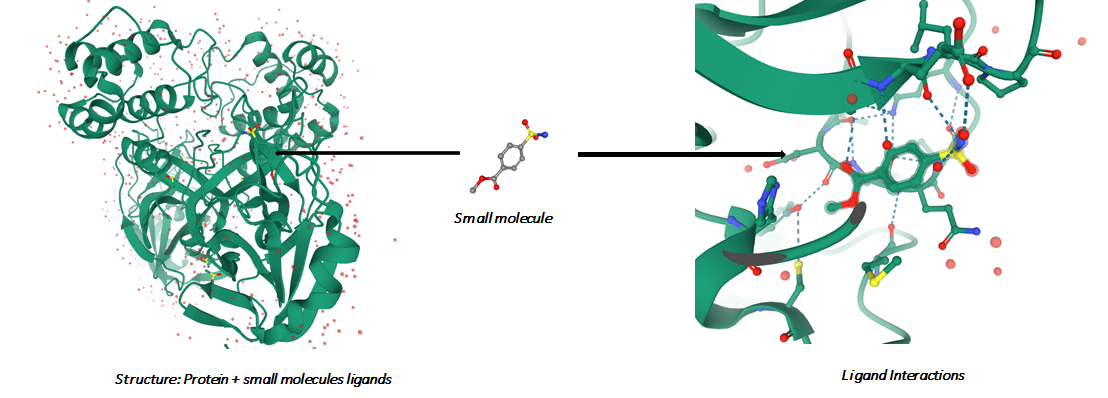

Research at the intersection of physics, chemistry, bioinformatics, and pharmacology is designed to model potentially possible chemical bonds and molecular configurations. In this way, the development of new drugs can be both cheaper and much faster.

# Drug Desing with PacMan

By modeling drug design as a “dynamic game”, we can use reinforcement learning to generate molecules with desired properties. Imagine drug design, but instead, the drug is replaced by PacMan.

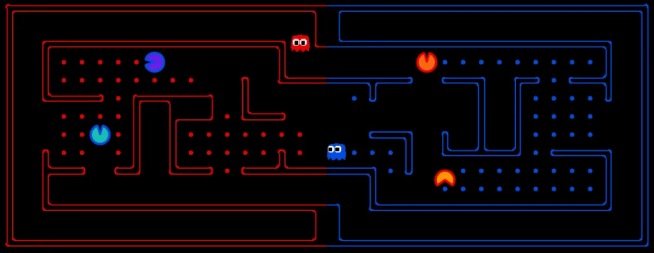

What is Reinforcement Learning?
Reinforcement learning is a type of machine learning. Unlike supervised learning and unsupervised learning, reinforcement learning doesn’t learn from data, instead it learns from experimenting.

Let’s take a look at how reinforcement learning can be used to help machines play PacMan.

There are two components which reinforcement learning comes down to:

> The Agent = PacMan

> The Critic = Positive Rewards & Negative Consequences
The reinforcement learning agent learns to play PacMan by experimenting with different actions. At first, the agent, “PacMan” moves randomly.

Through experimenting with difference random moves, the agent over time slowly learns actions associated with rewards and consequences. The agent gets rewarded for actions that lead to rewards like eating PacDots and gets punished for actions that lead to consequences like bumping into a ghost.

PacMan gets better by learning only repeat actions that lead to rewards, but not actions that lead to consequences.

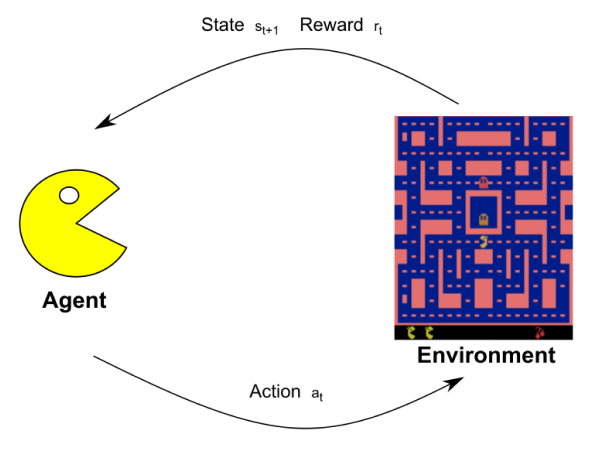

The repeated training process looks something like this:

> The agent, PacMan is assigned a state S⁰, which is the environment the agent “plays” in.

> Then the PacMan takes an action, A⁰ and moves for this specific example, it moves 7 units to the left. The agent has now moved to a new state, S¹.

> Since the PacMan ate 7 PacDots and is still alive, the agent gets rewarded +7.

To summarize: through experience, reinforcement learning optimizes actions that maximize rewards while minimizing negative consequences.

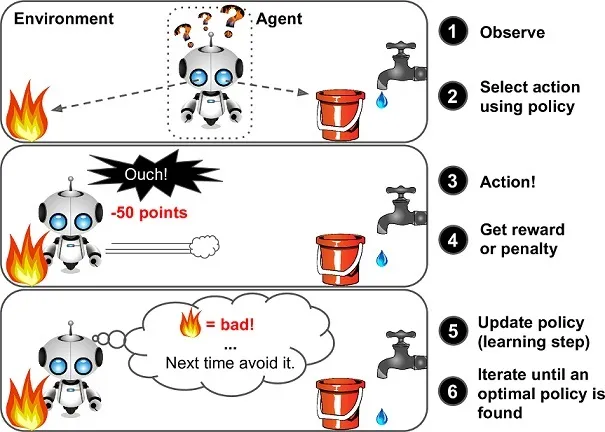

# Reinforcement Learning for Drug Design as Game


To model drug design as a game so that reinforcement learning can be applied for de nova drug design of molecules with desired properties, two separate models are combined together — a generative model which is responsible for generating novel molecules, and a (molecular) property prediction model which is responsible for predicting the user-specified property of molecules.

Unleashing the Power of Reinforcement Learning in Drug Design!

Imagine having a learning agent who is always on the hunt for the most effective drugs, a superhero in the world of pharmaceuticals. That's exactly what a generative model combined with a property prediction model does in the field of deep reinforcement learning for de novo drug design.

The generative model acts as the "reinforcement learning agent" and the property prediction model acts as the "critic" that assigns rewards or punishments based on a reward function. The reward function is key, as it determines the success of the reinforcement learning model's training.

In this particular case, the reward function is designed to motivate the agent to generate molecules with potent inhibitory effects against JAK2, maximizing the pIC-50 values in the process. The goal is to create the best possible drugs, and the reinforcement learning agent is constantly learning and evolving to get there.

# Neural networks as a biochemical testing ground


The discovery of new drugs is aimed at finding new chemical compounds with specific properties, usually therapeutic ones. In recent years, this field has become closely related to computer science, as it relies on machine learning techniques, which have recently become much more accessible. 

In drug discovery, machine learning approaches can be used for the following purposes:
> Predict the structure of targeted drugs

> Identify and refine promising variants

> Investigate the biological activity of new ligands

> Design models that predict the pharmacokinetics and 
Toxicological properties of candidate substances

Training with a teacher requires a marked (training) data set - on which the model is trained. Once trained, the model itself can start making predictions and formulating solutions as new data are acquired. Among teacher-assisted learning methods in biochemical problems, reference vector methods and artificial neural networks (ANNs), capable of extracting complex patterns in large datasets, are used.  
Teacherless learning identifies relationships or patterns in unlabeled data. The model learns on its own by observing lots of data and combining the patterns and relationships found into clusters.

> Sequential learning allows an agent (that is, an entity with a goal) to learn in an interactive environment by trial and error, evaluating the experience of interactions with that environment as positive and negative. Consequently, sequential learning is a variant of reinforcement learning.

# A rare opportunity to fight "forgotten" diseases

Today's topic is one that's sure to cause a stir in the world of drug discovery - a field that's about to undergo a major transformation. Pharmaceutical companies and their partners are all too familiar with the astronomical costs of bringing a new drug to market. With many drugs taking years to be studied and tested, it's no surprise that the price tag can soar to $2.5 billion or more.

But the high cost of development has another, more heart-wrenching consequence: it often leads to a neglect of certain classes of drugs, including diseases that disproportionately affect people in poor countries and are considered unprofitable to treat. This has resulted in a surge in the number of so-called "neglected diseases," including tropical diseases and rare diseases with low morbidity rates.

Despite affecting relatively few people individually, the total number of people affected by rare diseases is estimated to be a staggering 300 million. And the sad reality is, that number may be even higher, with experts estimating that about 30% of those suffering from a rare disease do not live to see their fifth birthday.

It's time for a change in the world of drug discovery, where innovation and compassion come together to tackle these neglected diseases and improve the lives of millions.

# Deep Learning usage in drug development

![](https://www.mdpi.com/ijms/ijms-22-09983/article_deploy/html/images/ijms-22-09983-g003.png)

The world of drug development has come a long way since the 1970s, when computers first made their mark in the field. Today, computer-aided drug discovery (CADD) technology is revolutionizing the way we discover new drugs, making it possible to significantly reduce costs and speed up the development process with just a few clicks.

With CADD, researchers can create vast databases of "pharmaceutical" molecules using the Monte Carlo method, and then virtually screen the structural formulas to identify the most promising candidates. This technology takes two basic approaches to molecular design: structural design and ligand-based drug discovery (LBDD).

Ligand-based drug discovery, also known as QSAR (quantitative structure-property relationship search), allows researchers to test which small molecules can connect with large protein molecules. This approach can be easily optimized and modeled using off-the-shelf Python libraries, making it an attractive option for drug discovery.

However, virtual molecules must still undergo preliminary evaluations of their ADMET parameters (absorption, distribution, metabolism, excretion, and toxicity) to determine if they are both therapeutically effective and safe for use.

Thanks to CADD and the advances in technology, the process of discovering new drugs has become much more efficient and cost-effective. With the ability to quickly screen vast databases of molecular structures and assess their potential, we are closer than ever to finding the next breakthrough in the world of drug development.

# Finally, the code: 🤗

# Unleashing the Power of EDA in Drug Design

> **Unveiling the Potential of EDA:** By examining the distributions, relationships, and variations in the data, EDA unveils valuable information about the properties and behaviors of molecules. From identifying outliers and missing data to exploring structure-activity relationships, EDA plays a pivotal role in guiding subsequent steps in the drug design pipeline. It enables researchers to make informed decisions, select appropriate modeling approaches, and uncover novel avenues for therapeutic intervention.

> **Tools and Techniques for Data Exploration and EDA:** A myriad of tools and techniques are available to facilitate data exploration and EDA in drug design. Advanced visualization tools, such as heatmaps, scatter plots, and network graphs, enable researchers to visually explore and interpret complex chemical data. Statistical methods, including principal component analysis (PCA), clustering algorithms, and correlation analysis, provide insights into the underlying structure and relationships within the data. Machine learning approaches, such as random forest and support vector machines, can aid in feature selection, predictive modeling, and the identification of key molecular descriptors.

> **The Impact on Drug Discovery:** The integration of data exploration and EDA into the drug discovery process has the potential to revolutionize the field by enabling researchers to identify novel drug targets, optimize lead compounds, and accelerate the development of effective therapies. By leveraging the power of data-driven insights, scientists can make informed decisions, prioritize resources, and minimize the risk of late-stage failures. Data exploration and EDA also facilitate the identification of off-target effects, potential drug-drug interactions, and insights into mechanisms of action, leading to safer and more effective medications

In [1]:
!pip install rdkit >& dev_null

In [2]:
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, Descriptors, AllChem
from rdkit.Chem.Draw import IPythonConsole

from itertools import combinations

import IPython
from IPython.display import display, Image
from PIL import Image

import numpy as np
import pandas as pd

import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1ccc - what is this?
 SMILES (Simplified Molecular Input Line Entry System) is a way of representing a chemical molecule as a string of characters. The string consists of symbols that correspond to the chemical elements present in the molecule, as well as brackets and other symbols that indicate the bonds between the elements and any stereo chemical information.

In the SMILES string you provided, each character represents a specific element or bond in the molecule:

>O represents an oxygen atom

> S represents a sulfur atom
( and ) are used to specify branches in the molecule

> = represents a double bond 

> N represents a nitrogen atom

> c represents a carbon atom

> 1, 2, etc. are used to specify stereochemistry

> s represents a sulfur atom in a sulfoxide functional group

So the SMILES string you provided describes the molecular structure of oxazepam, which is a benzodiazepine derivative used as a sedative and anxiolytic drug.


In [3]:
df = pd.read_csv("/kaggle/input/big-molecules-smiles-dataset/SMILES_Big_Data_Set.csv")
# df = pd.read_csv("../input/zinc250k/250k_rndm_zinc_drugs_clean_3.csv")

df.head(5)

,SMILES,pIC50,mol,num_atoms,logP
0,O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1,4.26,<rdkit.Chem.rdchem.Mol object at 0x7f59df45bc30>,25,4.1591
1,O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...,4.34,<rdkit.Chem.rdchem.Mol object at 0x7f59a320c9e0>,36,3.6743
2,NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO,4.53,<rdkit.Chem.rdchem.Mol object at 0x7f59a320cac0>,23,1.5361
3,NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21,4.56,<rdkit.Chem.rdchem.Mol object at 0x7f59a320cba0>,22,0.9510
4,CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1,4.59,<rdkit.Chem.rdchem.Mol object at 0x7f59a320c7b0>,21,3.2130


'Click on the photo to zoom it'

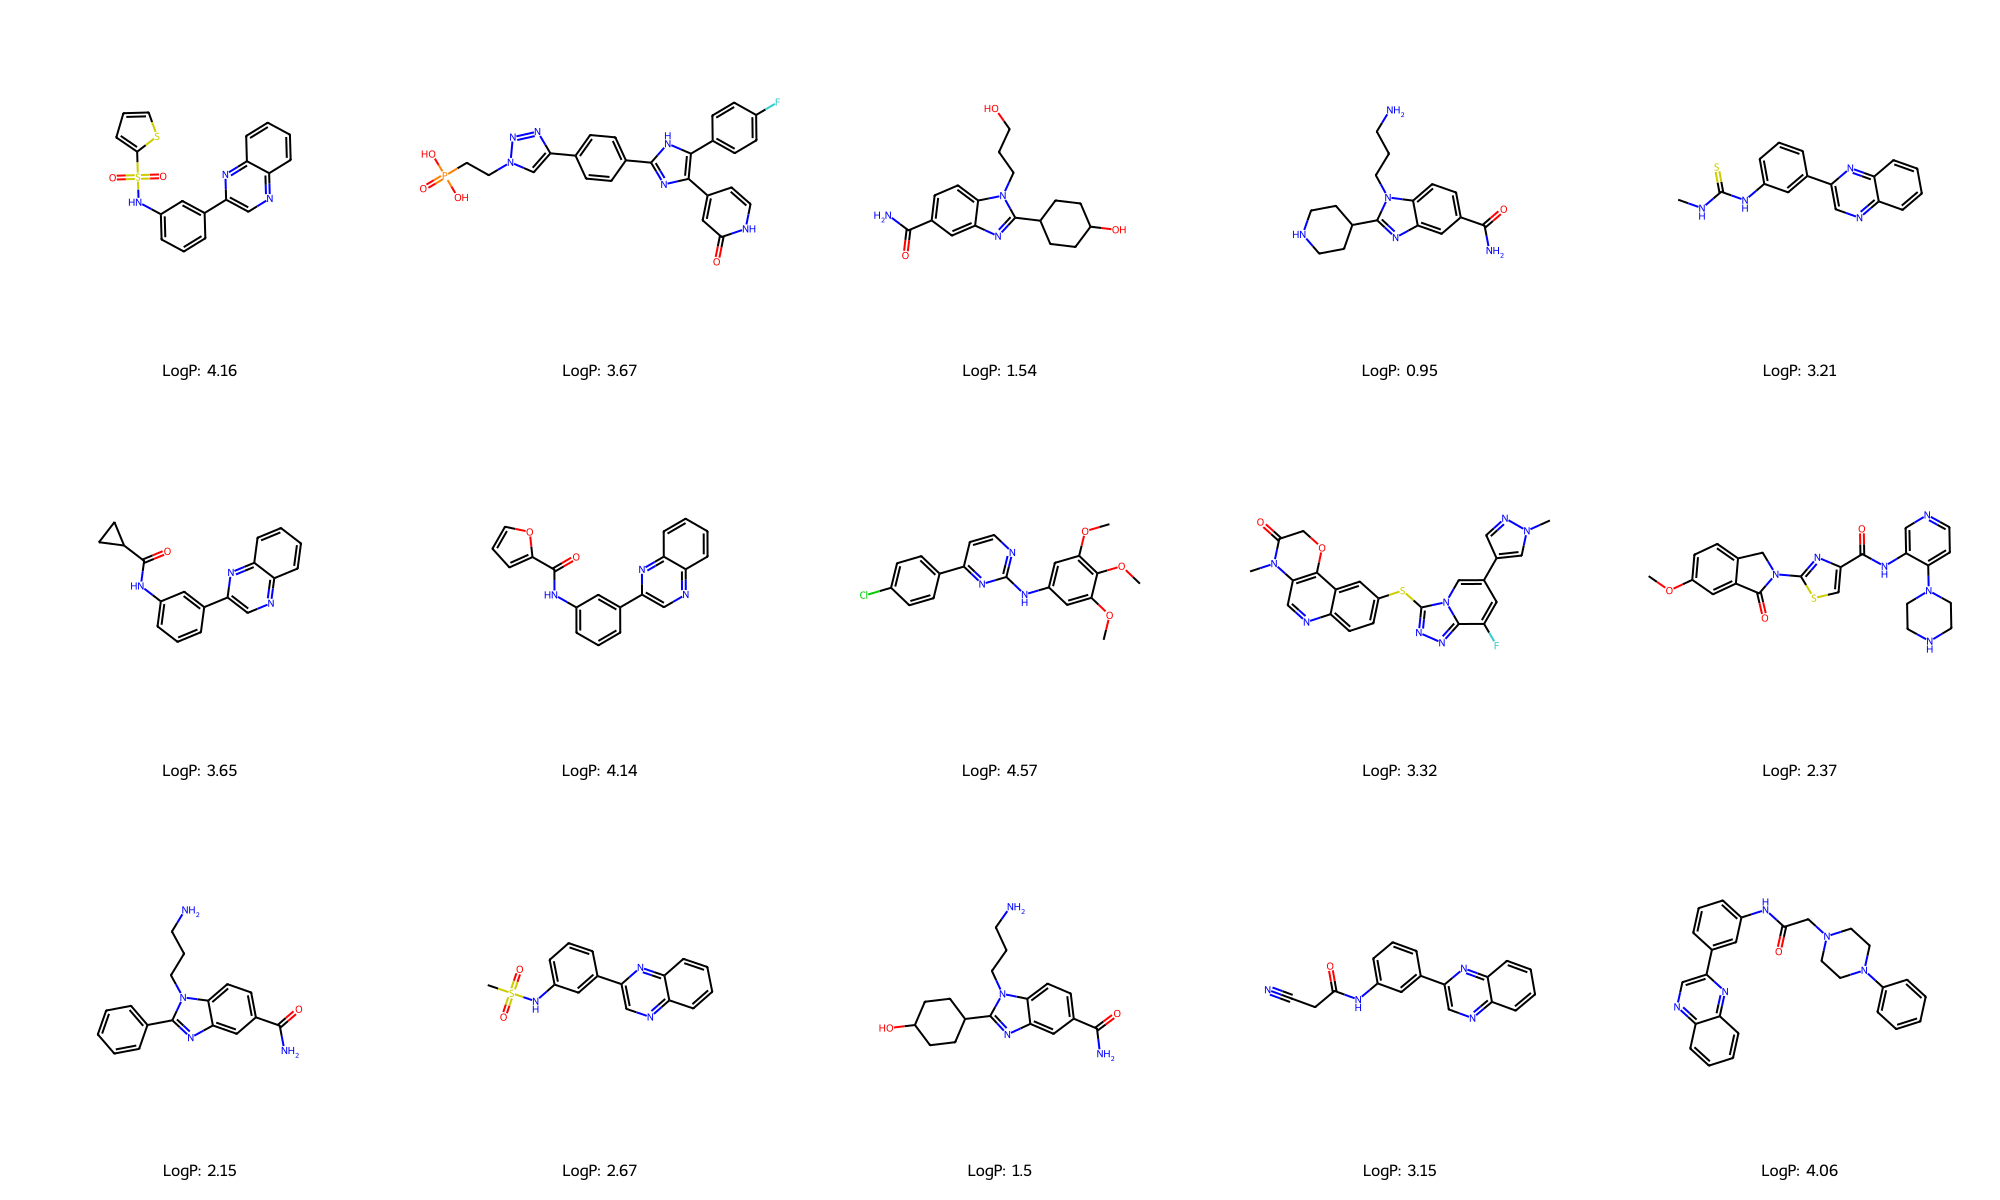

In [4]:
def show_smiles(smiles):
  """
  generate 2D representations of the molecules and color-code them by logP
  :param data_frame: list of smiles
  """
  # Convert the SMILES strings to RDKit molecules
  molecules = [Chem.MolFromSmiles(smile) for smile in smiles]

  # Draw the first molecules
  img = Draw.MolsToGridImage(molecules[:15], molsPerRow=5, subImgSize=(400,400),
                             legends=[f'LogP: {round(x, 2)}' for x in df['logP']], 
                             returnPNG=False).save("molecules.png")
                             
  from IPython.display import display, Image
  display("Click on the photo to zoom it")
  display(Image("molecules.png"))

show_smiles(df["SMILES"])

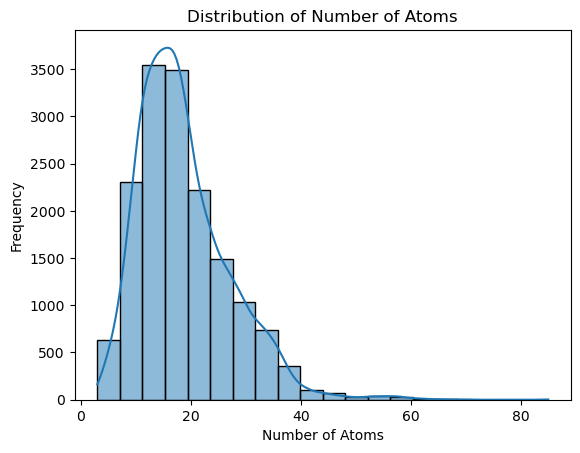

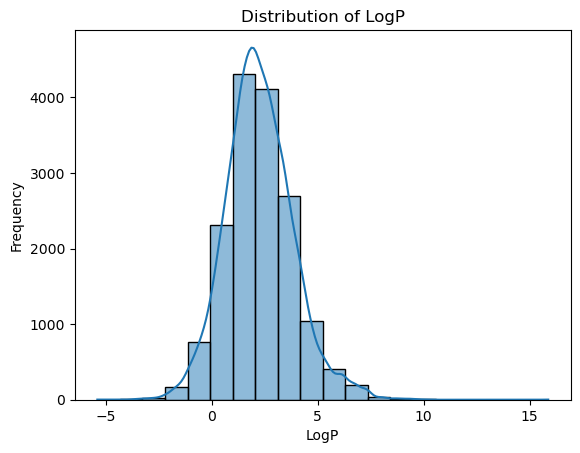

In [5]:
def histogram_of_distribution(data_frame):
  """
  visualize the distribution Number of Atoms and Distribution of LogP 
  :param data_frame: DF with num_atoms & logP
  """
  sns.histplot(data=df, x='num_atoms', bins=20, kde=True)
  plt.title('Distribution of Number of Atoms')
  plt.xlabel('Number of Atoms')
  plt.ylabel('Frequency')
  plt.show()

  sns.histplot(data=df, x='logP', bins=20, kde=True)
  plt.title('Distribution of LogP')
  plt.xlabel('LogP')
  plt.ylabel('Frequency')
  plt.show()

histogram_of_distribution(df)

In [ ]:
def num_atoms_and_logP(data_frame):
  """
  plot the relationship between logP and number of atoms
  :param data_frame: DF with num_atoms & logP
  """
  sns.scatterplot(data=data_frame, x='num_atoms', y='logP')
  sns.despine()
  sns.set_style("whitegrid")
  plt.title('LogP vs. Number of Atoms')
  plt.xlabel('Number of Atoms')
  plt.ylabel('LogP')
  plt.show()

num_atoms_and_logP(df)

In [ ]:
def molecular_weight(smiles_list, pIC50):
  """
  Plot a scatter plot of pIC50 values against molecular weight
  :param smiles_list: A list of SMILES strings
  :param pIC50: A list of SMILES strings
  """
  plt.scatter(smiles_list, pIC50)
  plt.xlabel("Molecular Weight")
  plt.ylabel("pIC50")
  plt.title("pIC50 vs Molecular Weight")
  plt.show()

# molecular_weight(df["SMILES"], df["pIC50"])

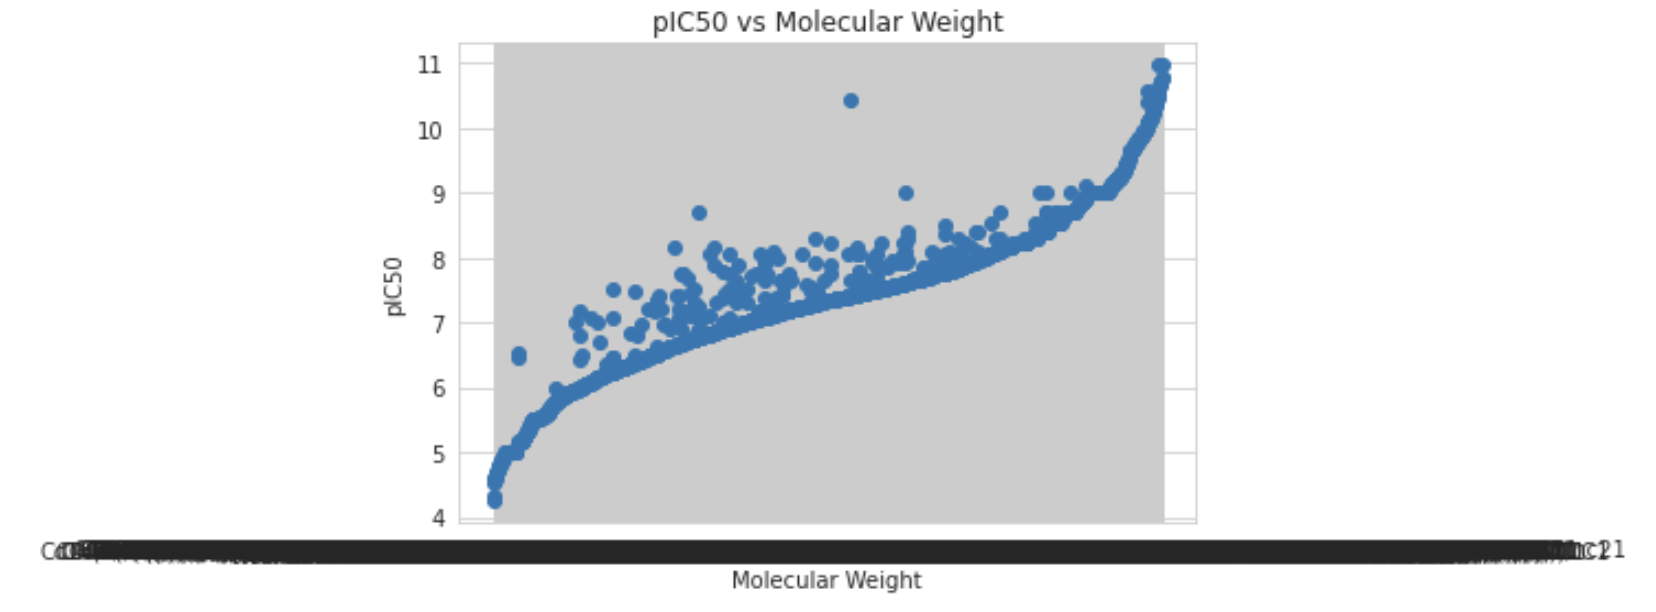

In [ ]:
html_code = \
'''
<p>This is a 3D object you can interact with it!</p>
<iframe style="width: 900px; height: 900px;" frameborder="0" src="https://embed.molview.org/v1/?mode=balls&cid=127050563"></iframe>
'''
display(IPython.display.HTML(html_code))

In [ ]:
def atom_frequency(smiles_list):
    """
    frequency of different atom types in SMILES
    :param smiles_list: A list of SMILES strings
    """
    atom_counts = []
    for smiles in smiles_list:
        # Convert the SMILES string to an RDKit molecule object
        mol = Chem.MolFromSmiles(smiles)
        # Get the atoms in the molecule
        atoms = mol.GetAtoms()
        # Add the symbol for each atom to the atom_counts list
        atom_counts.extend([atom.GetSymbol() for atom in atoms])

    # Create a pandas series with the counts of each atom type
    plot_data = pd.Series(atom_counts).value_counts().sort_index()
    sns.barplot(x=plot_data.index, y=plot_data.values)

atom_frequency(df['SMILES'])

In [ ]:
def bond_frequency(smiles_list):
    """
    Frequency of different bond types
    :param smiles_list: A list of SMILES strings
    """
    bond_counts = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        bonds = mol.GetBonds()
        # Loop through each bond in the molecule and append its bond type to the bond_counts list
        bond_counts.extend([bond.GetBondTypeAsDouble() for bond in bonds])
    # Count the frequency of each bond type and sort the counts in ascending order
    plot_data = pd.Series(bond_counts).value_counts().sort_index()
    sns.barplot(x=plot_data.index, y=plot_data.values)

bond_frequency(df['SMILES'])

In [ ]:
def atom_bond_heatmap(smiles_list):
    """
    The pairwise occurrences of different atom and bond types
    :param smiles_list: A list of SMILES strings
    """
    # Define the atom and bond types to consider
    atom_types = ['C', 'N', 'O', 'S', 'Cl', 'Br', 'P', 'F', 'I', 'Si', 'As', 'B', 'Se']
    bond_types = [1.0, 1.5, 2.0, 3.0]
    # Initialize the data array with zeros
    data = np.zeros((len(atom_types), len(bond_types)))
    for smiles in smiles_list:
        # Convert the SMILES string to a molecule object
        mol = Chem.MolFromSmiles(smiles)
        # Get the atoms and bonds in the molecule
        atoms = mol.GetAtoms()
        bonds = mol.GetBonds()
        # Get the atoms and bonds in the molecule
        for bond in bonds:
            # Get the bond type and index in the bond_types list
            bond_type = bond.GetBondTypeAsDouble()
            bond_idx = bond_types.index(bond_type)
            # Update the data array for each atom in the bond
            for atom in [bond.GetBeginAtom(), bond.GetEndAtom()]:
                # Get the atom type and index in the atom_types list
                atom_type = atom.GetSymbol()
                atom_idx = atom_types.index(atom_type)
                # Increment the count in the data array for the atom-bond pair
                data[atom_idx, bond_idx] += 1
    sns.heatmap(data, xticklabels=bond_types, yticklabels=atom_types)

atom_bond_heatmap(df["SMILES"])

In [ ]:
def fingerprint_tsne(smiles_list):
    """
    Plot a t-SNE plot of the molecular fingerprints for a list of SMILES strings
    :param smiles_list: A list of SMILES strings
    """
    from sklearn.manifold import TSNE
    from rdkit.Chem import AllChem
    # Generate molecular fingerprints using Morgan algorithm with radius=2
    fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(smiles),
                                                 2) for smiles in smiles_list]
    # Convert the list of fingerprints to a numpy array
    fps_array = np.asarray(fps)
    tsne = TSNE(n_components=2)
    tsne_result = tsne.fit_transform(fps_array)
    sns.scatterplot(x=tsne_result[:,0], y=tsne_result[:,1])

fingerprint_tsne(df['SMILES'])

Here I tried to visualizing Molecular similarity networks. With this plot you can use the molecular fingerprints generated from SMILES and build a similarity network where similar molecules are connected by edges

In [ ]:
def molecular_similarity(smiles_list):
  # Generate molecular fingerprints using Morgan algorithm with radius=2
  fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(smiles), 2) for smiles in smiles_list]

  # Calculate pairwise similarity scores using *(Tanimoto similarity coefficient)
  similarity_scores = []
  for fp1, fp2 in combinations(fps, 2):
      similarity_score = DataStructs.TanimotoSimilarity(fp1, fp2)
      similarity_scores.append(similarity_score)

  # Build a similarity network using NetworkX
  G = nx.Graph()
  for idx, smiles in enumerate(smiles_list):
      G.add_node(idx, smiles=smiles)
  for (i, j), weight in zip(combinations(range(len(smiles_list)), 2), similarity_scores):
      G.add_edge(i, j, weight=weight)

  # Visualize the network
  pos = nx.spring_layout(G)
  nx.draw(G, pos=pos, node_size=150, width=0.3, edge_color='gray', with_labels=False)
  plt.show()

short_df_for_grahp = df.head(15)
molecular_similarity(short_df_for_grahp["SMILES"])

*Tanimoto similarity coefficient: is a measure of how similar two sets of data are. It's calculated by taking the number of elements that are common to both sets and dividing it by the total number of elements in both sets. This gives us a value between 0 and 1, where 1 means the sets are identical and 0 means they have no elements in common. This measure is often used in data mining and machine learning to compare the similarity of two sets of features.

Mathematically, the Tanimoto similarity coefficient between two sets A and B is calculated as:

T(A, B) = |A ∩ B| / |A ∪ B|

And graph with a picture of molecule, will look like this: 

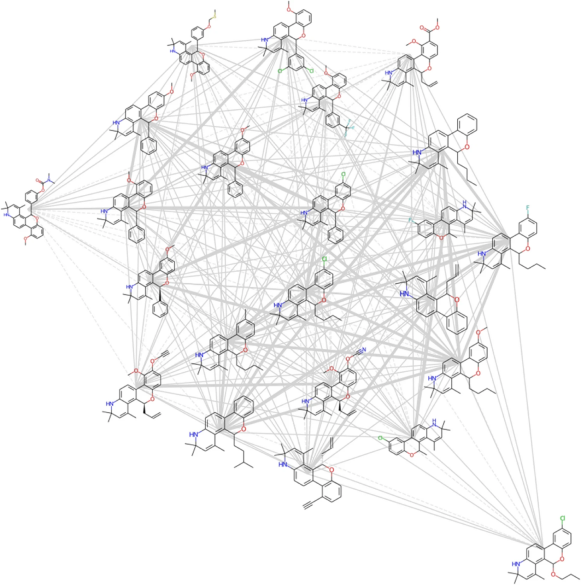

this picture from: https://jcheminf.biomedcentral.com/articles/10.1186/s13321-022-00664-x 

# Designing an Effective Deep Reinforcement Learning Model for Drug Design: A Comprehensive Guide

**Defining the State Space:**

In drug design, the state space represents the set of features that describe the current state of a molecule. These features can include molecular descriptors, such as molecular weight, lipophilicity, and hydrogen bonding patterns. It is essential to carefully select and preprocess these features to ensure that they capture relevant information and facilitate effective learning by the DRL model. Additionally, techniques such as molecular graph representation and attention mechanisms can be employed to capture the structural properties of molecules in a more comprehensive manner.

**Action Space and Decision-Making:**

The action space of a DRL model in drug design corresponds to the set of possible actions that the model can take at each state. These actions can include modifications to the molecular structure, such as adding or removing specific functional groups. The design of the action space is crucial to ensure that it encompasses a wide range of chemically meaningful modifications while being computationally tractable. Balancing exploration and exploitation is a critical aspect of decision-making in DRL models, as it determines the model's ability to explore new chemical space while maximizing rewards.

**Reward Design:**

The reward function is a pivotal component of the DRL model, as it shapes the learning process and drives the model towards desired outcomes. In drug design, defining an appropriate reward function is a complex task. It involves capturing multiple objectives, such as molecular potency, selectivity, and properties related to drug-likeness. Balancing these objectives and avoiding bias towards specific properties is essential to ensure a well-rounded and effective reward function. Additionally, techniques like reward shaping and curriculum learning can be employed to guide the learning process and promote the discovery of molecules with desired properties.

**Training and Optimization:**

Training a DRL model for drug design requires careful consideration of various factors. The selection of an appropriate optimization algorithm, such as stochastic gradient descent (SGD) or Adam, plays a crucial role in efficiently updating the model's parameters. Exploratory strategies, such as epsilon-greedy or softmax exploration, are employed to balance exploration and exploitation during training. Additionally, techniques like experience replay, target networks, and batch normalization can enhance the stability and convergence of the DRL model during training.

**Validation and Performance Assessment:**

Validating and assessing the performance of a DRL model in drug design is essential to ensure its reliability and effectiveness. Evaluation metrics such as predictive accuracy, diversity of generated molecules, and novelty of the discovered compounds are employed to assess the model's performance. Comparisons with existing methods and experimental validation of predicted properties further validate the utility and reliability of the DRL model.

**Conclusion:**

Designing an effective Deep Reinforcement Learning model for drug design requires a comprehensive understanding of the underlying principles and considerations. By carefully selecting appropriate neural network architectures, defining the state space, action space, and reward function, optimizing training strategies, and rigorously evaluating the model's performance, researchers can unlock the full potential of DRL in accelerating the discovery of innovative therapeutics. As the field of drug design continues to evolve, the development of advanced DRL models will undoubtedly play a pivotal role in shaping the future of pharmaceutical research.

This is simple code demonstrates the use of a Deep Reinforcement Learning (DRL) agent for drug design. (The main model is under this example model)

The output of this model is: 

1) Molecular properties dictionary:
> {'Molecular Weight': 180.15899999999996, 'LogP': 1.3101, 'H-Bond Donor Count': 1, 'H-Bond Acceptor Count': 3}

These are the calculated molecular properties of the compound represented by the SMILES string 'CC(=O)OC1=CC=CC=C1C(=O)O'. The properties include the molecular weight, LogP (partition coefficient), H-Bond Donor Count, and H-Bond Acceptor Count.

2) Model output:

> [[19.104523 54.602215 39.99386]]

This is the output of the neural network model. It predicts the Q-values for each action given the input state (molecular properties). In this case, the model predicts Q-values for three possible actions.

3) Reconstructed SMILES:

> CC(=O)Oc1ccccc1C(=O)O

This is the reconstructed SMILES string obtained from the model's prediction. It represents the predicted compound based on the input molecular properties.

4) Visualization of the molecule:

The molecule represented by the reconstructed SMILES, 'CC(=O)Oc1ccccc1C(=O)O', is visualized as an image using RDKit's MolToImage function. The image of the molecule is displayed.

This code implements a Deep Q-Network-based agent for drug design using a reinforcement learning approach. The agent interacts with the environment to generate chemical structures and learns to maximize a reward based on the similarity to a target structure.

/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZTVN10tenso

{'Molecular Weight': 180.15899999999996, 'LogP': 1.3101, 'H-Bond Donor Count': 1, 'H-Bond Acceptor Count': 3}
1/1 [==============================] - 0s 161ms/step
Model Output: [[ 20.85065  -16.921696  56.36783 ]]
Reconstructed SMILES: CC(=O)Oc1ccccc1C(=O)O


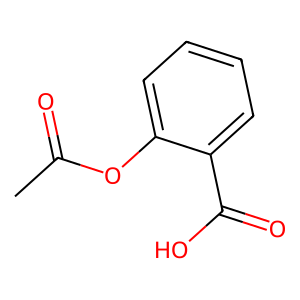

In [6]:
import re
import random

import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Draw import MolToImage

from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential


class DRLAgent:
    """
    Deep Reinforcement Learning Agent

    Args:
        state_size (int): Size of the state space
        action_size (int): Size of the action space
    """

    def __init__(self, state_size, action_size, selected_X_train):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        # discount rate
        self.gamma = 0.95
        # exploration rate
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.selected_X_train = selected_X_train
        self.model = self._build_model(selected_X_train)
        # target model for stability
        self.target_model = self._build_model(selected_X_train) 
        self.update_target_model()

    def _build_model(self, selected_X_train):
        """
        Build the Deep Q-Network model

        Returns:
            model (Sequential): Deep Q-Network model
        """
        model = Sequential()
        model.add(Dense(32, input_shape=(selected_X_train.shape[1],), activation='relu'))
        model.add(Dense(16, activation='relu'))
        model.add(Dense(self.action_size, activation='linear'))
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        """Update the target model weights with the current model weights"""
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        """
        Store the experience in the replay memory

        Args:
            state (ndarray): Current state
            action (int): Action taken
            reward (float): Reward received
            next_state (ndarray): Next state
            done (bool): Whether the episode is done
        """
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        """
        Choose an action given the current state

        Args:
            state (ndarray): Current state

        Returns:
            action (int): Chosen action
        """
        if np.random.rand() <= self.epsilon:
            return np.random.randint(self.action_size)
        if state is None:
            state = np.zeros((1, self.state_size))
        else:
            state = state.reshape(1, self.state_size)
        act_values = self.model.predict(state)
        return np.argmax(act_values[0])

    def replay(self, batch_size):
        """
        Train the model by replaying experiences from the replay memory

        Args:
            batch_size (int): Size of the minibatch
        """
        # Sample a minibatch of experiences from the replay memory
        minibatch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in minibatch:
            if state is not None:
                if not done:
                    # Calculate the target value using the target model
                    target = (reward + self.gamma * np.amax(self.target_model.predict(next_state)[0]))
                else:
                    target = reward
                # Make the agent approximately map the current state to future discounted reward
                target_f = self.model.predict(state)
                target_f[0][action] = target
                # Train the model using the current state and target value
                self.model.fit(state, target_f, epochs=1, verbose=0)
        # Decay the exploration rate
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def load(self, name):
        """Load the model weights from a file"""
        self.model.load_weights(name)

    def save(self, name):
        """Save the model weights to a file"""
        self.model.save_weights(name)


def preprocess_smiles(smiles):
    """
    Preprocess the SMILES string by removing salts and stereochemistry information

    Args:
        smiles (str): SMILES string

    Returns:
        preprocessed_smiles (str): Preprocessed SMILES string
    """
    # Remove salts
    preprocessed_smiles = re.sub(r'\[.*?\]', '', smiles)
    # Remove stereochemistry information
    preprocessed_smiles = re.sub(r'[@]\S*', '', preprocessed_smiles)
    return preprocessed_smiles


def calculate_molecular_properties(smiles):
    """
    Calculate molecular properties of a compound given its SMILES string

    Args:
        smiles (str): SMILES string

    Returns:
        properties (dict): Dictionary of molecular properties
    """
    molecule = Chem.MolFromSmiles(smiles)
    properties = {}

    if molecule is not None:
        properties['Molecular Weight'] = Descriptors.MolWt(molecule)
        properties['LogP'] = Descriptors.MolLogP(molecule)
        properties['H-Bond Donor Count'] = Descriptors.NumHDonors(molecule)
        properties['H-Bond Acceptor Count'] = Descriptors.NumHAcceptors(molecule)

    return properties


if __name__ == '__main__':
    smiles = 'CC(=O)OC1=CC=CC=C1C(=O)O'
    preprocessed_smiles = preprocess_smiles(smiles)
    properties = calculate_molecular_properties(preprocessed_smiles)
    print(properties) # {'Molecular Weight': 180.15899999999996, 'LogP': 1.3101, 'H-Bond Donor Count': 1, 'H-Bond Acceptor Count': 3}
    
    # Convert the properties dictionary to a NumPy array
    selected_X_train = np.array(list(properties.values())).reshape(1, -1)

    agent = DRLAgent(state_size=selected_X_train.shape[1], action_size=3, selected_X_train=selected_X_train)

    # Get the model's output for the selected input
    output = agent.model.predict(selected_X_train)
    print("Model Output:", output)

    # Obtain the SMILES representation of the molecule after processing with the model
    reconstructed_smiles = Chem.MolToSmiles(Chem.MolFromSmiles(preprocessed_smiles))
    print("Reconstructed SMILES:", reconstructed_smiles)
    
    mol = Chem.MolFromSmiles(reconstructed_smiles)
    if mol is None:
        print(f"Error generating molecule from SMILES: {reconstructed_smiles}")
    else:
        display(MolToImage(mol))


In [7]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import re
import random

from rdkit.Chem import QED
from rdkit.Chem import Crippen

import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Draw import MolToImage

from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

from rdkit import Chem
from rdkit.Chem import AllChem

class DRLAgent:
    """
    Deep Reinforcement Learning Agent

    Args:
        state_size (int): Size of the state space
        action_size (int): Size of the action space
    """

    def __init__(self, state_size, action_size, selected_X_train, num_actions):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        # discount rate
        self.gamma = 0.95
        # exploration rate
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.selected_X_train = selected_X_train
        self.model = self._build_model(selected_X_train)
        # target model for stability
        self.target_model = self._build_model(selected_X_train) 
        self.update_target_model()
        self.num_actions = num_actions 

    def _build_model(self, selected_X_train):
        """
        Build the Deep Q-Network model

        Returns:
            model (Sequential): Deep Q-Network model
        """
        model = Sequential()
        model.add(Dense(128, input_shape=(selected_X_train.shape[1],), activation='relu'))
        model.add(Dense(128, activation='relu'))
        model.add(Dense(128, activation='linear'))
#         model.add(Dense(num_actions, activation='linear'))
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        """Update the target model weights with the current model weights"""
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        """
        Store the experience in the replay memory

        Args:
            state (ndarray): Current state
            action (int): Action taken
            reward (float): Reward received
            next_state (ndarray): Next state
            done (bool): Whether the episode is done
        """
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        """
        Choose an action given the current state

        Args:
            state (ndarray): Current state

        Returns:
            action (int): Chosen action
        """
        if np.random.rand() <= self.epsilon:
            return np.random.randint(self.action_size)
        if state is None:
            state = np.zeros((1, self.state_size))
        else:
            state = state.reshape(1, self.state_size)
        act_values = self.model.predict(state)
        return np.argmax(act_values[0])


    def replay(self, batch_size):
        """
        Train the model by replaying experiences from the replay memory

        Args:
            batch_size (int): Size of the minibatch
        """
        # Sample a minibatch of experiences from the replay memory
        minibatch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in minibatch:
            if state is not None:
                if not done:
                    # Calculate the target value using the target model
                    target = (reward + self.gamma * np.amax(self.target_model.predict(next_state.reshape(1, self.state_size))[0]))
                else:
                    target = reward
                # Make the agent approximately map the current state to future discounted reward
                target_f = self.model.predict(state.reshape(1, self.state_size))
                target_f[0][action] = target
                # Train the model using the current state and target value
                self.model.fit(state.reshape(1, self.state_size), target_f, epochs=1, verbose=0)
        # Decay the exploration rate
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
    def load(self, name):
        """
        Load the model weights from a file

        Args:
            name (str): Name of the file
        """
        self.model.load_weights(name)

    def save(self, name):
        """
        Save the model weights to a file

        Args:
            name (str): Name of the file
        """
        self.model.save_weights(name)


# class DrugDesignEnv:
#     """
#     Drug Design Environment

#     Args:
#         num_features (int): Number of features for each molecule
#         num_actions (int): Number of actions (molecules) to choose from
#         X_train (list): List of preprocessed SMILES strings for training
#         y_train (ndarray): Array of corresponding target values for training
#     """
# #     def __init__(self, num_features, num_actions, X_train, y_train):
# #         self.num_features = num_features
# #         self.num_actions = num_actions
# #         self.current_state = np.zeros((num_features,))
# #         self.reward = 0
# #         # represents a target vector or pattern that the agent is trying to match or approximate
# #         self.target = np.ones((self.num_features,))
# #         self.max_steps = 10
# #         self.step_count = 0
# #         self.generated_smiles = []
# #         self.X_train = X_train
# #         self.y_train = y_train

# #     def _get_reward(self):
# #         """Compute the reward based on the similarity between the current state and the target"""
# #         similarity = np.dot(self.current_state, self.target)
# #         return similarity / self.num_actions
        
# #     def _is_done(self):
# #         """Check if the maximum number of steps has been reached"""
# #         self.step_count += 1
# #         return self.step_count >= self.max_steps

# #     def get_smiles(self):
# #         """Return the SMILES string representation of the current state."""
# #         binary_string = ''.join([str(int(x)) for x in self.current_state])
# #         return binary_string


# #     def step(self, action):
# #         """
# #         Execute a step in the environment
# #         Args:
# #             action (int): The action taken by the agent

# #         Returns:
# #             Tuple[np.ndarray, float, bool]: Tuple containing the next state, reward, and done flag
# #         """
# #         # Ensure the action is within the valid range
# #         action = max(0, min(action, self.num_actions - 1))
# #         # Initialize the next state
# #         next_state = np.zeros((self.num_features,))
# #         # Set the selected action to 1 in the next state
# #         next_state[action] = 1.0
# #         # Update the current state
# #         self.current_state = next_state
# #         # Compute the reward based on the current state
# #         reward = self._get_reward()
# #         # Check if the episode is done
# #         done = self._is_done()
# #         self.generated_smiles.append(action)
# #         return self.current_state, reward, done

#     def __init__(self, num_features, num_actions, X_train, y_train):
#         self.num_features = num_features
#         self.num_actions = num_actions
#         self.current_state = np.zeros((num_features,))
#         self.reward = 0
#         self.target = np.ones((self.num_features,))  # The target could be more complex, but this is a placeholder
#         self.max_steps = 10
#         self.step_count = 0
#         self.generated_smiles = []
#         self.X_train = X_train
#         self.y_train = y_train
    

#     def _calculate_cosine_similarity(self, state, target):
#         """Calculate the cosine similarity between the current state and the target."""
#         similarity = cosine_similarity(state.reshape(1, -1), target.reshape(1, -1))[0][0]
#         return similarity

#     def _molecular_properties_reward(self, mol):
#         """Calculate reward based on molecular properties like QED, molecular weight, etc."""
#         try:
#             qed_value = QED.qed(mol)  # QED score as a reward (between 0 and 1)
#             mol_weight = Descriptors.MolWt(mol)  # Molecular weight
#             logp = Crippen.MolLogP(mol)  # LogP for solubility
            
#             # You can adjust weights based on your objective
#             if mol_weight < 500:  # Reward for drug-like molecular weight
#                 weight_reward = 1.0
#             else:
#                 weight_reward = -1.0  # Penalty for overly large molecules
            
#             if logp < 5.0:  # Reward for LogP within drug-like range
#                 logp_reward = 1.0
#             else:
#                 logp_reward = -1.0
            
#             return qed_value + weight_reward + logp_reward
#         except:
#             return -5.0  # Heavy penalty for invalid molecules
#     def get_smiles(self):
#         """Return the SMILES string representation of the current state."""
#         # Convert the current state back to a SMILES string
#         active_indices = np.where(self.current_state == 1)[0]
#         if len(active_indices) == 0:
#             return ''  # Return empty if no actions taken
#         # Construct a simple binary string as a placeholder for SMILES
#         binary_string = ''.join([str(int(x)) for x in self.current_state])
#         return binary_string  # You might want to convert this to actual SMILES in a meaningful way
    
#     def _is_done(self):
#         """Check if the maximum number of steps has been reached."""
#         self.step_count += 1
#         return self.step_count >= self.max_steps
    
    
    
# #     def _get_reward(self):
# #         """Compute the reward based on the similarity and molecular properties."""
# #         # Calculate similarity-based reward
# #         similarity_reward = self._calculate_cosine_similarity(self.current_state, self.target)

# #         # Convert the current state to a SMILES string
# #         smiles_string = self.get_smiles()
# #         mol = Chem.MolFromSmiles(smiles_string)
        
# #         if mol is None:
# #             # Invalid molecule, penalize heavily
# #             return -10.0

# #         # Calculate reward from molecular properties
# #         properties_reward = self._molecular_properties_reward(mol)

# #         # Combine the similarity and properties rewards
# #         total_reward = 0.7 * similarity_reward + 0.3 * properties_reward  # Adjust weights as needed

# #         return total_reward



#         def _get_reward(self):
#         """Compute the reward based on the similarity between the current state and the target."""
#         # Calculate cosine similarity between the current state and the target state
#         similarity = np.dot(self.current_state, self.target) / (np.linalg.norm(self.current_state) * np.linalg.norm(self.target) + 1e-5)

#         # Penalize negative similarity and reward positive similarity
#         if similarity > 0:
#             reward = similarity * 10
#         else:
#             reward = similarity * 10  # Penalize more for negative values

#         return reward

     
    
    
#     def step(self, action):
#         """Execute a step in the environment."""
#         # Ensure the action is within the valid range
#         action = max(0, min(action, self.num_actions - 1))
#         # Initialize the next state
#         next_state = np.zeros((self.num_features,))
#         # Set the selected action to 1 in the next state
#         next_state[action] = 1.0
#         # Update the current state
#         self.current_state = next_state
#         # Compute the reward based on the current state
#         reward = self._get_reward()
#         # Check if the episode is done
#         done = self._is_done()
#         self.generated_smiles.append(action)
#         return self.current_state, reward, done

#     def reset(self):
#         """Reset the environment"""
#         self.current_state = np.zeros((self.num_features,))
#         self.generated_smiles = []
#         return self.current_state

    
#     def get_smiles(self):
        
#         """Return the SMILES string representation of the current state."""
        
#         # Convert the current state back to a SMILES string
#         active_indices = np.where(self.current_state == 1)[0]
#         if len(active_indices) == 0:
#             return ''  # Return empty if no actions taken
#         # Construct a simple binary string as a placeholder for SMILES
#         binary_string = ''.join([str(int(x)) for x in self.current_state])
#         return binary_string  # You might want to convert this to actual SMILES in a meaningful way
class DrugDesignEnv:
    """
    Drug Design Environment

    Args:
        num_features (int): Number of features for each molecule
        num_actions (int): Number of actions (molecules) to choose from
        X_train (list): List of preprocessed SMILES strings for training
        y_train (ndarray): Array of corresponding target values for training
    """
    def __init__(self, num_features, num_actions, X_train, y_train):
        self.num_features = num_features
        self.num_actions = num_actions
        self.current_state = np.zeros((num_features,))
        self.reward = 0
        self.target = np.ones((self.num_features,))  # Placeholder target
        self.max_steps = 10
        self.step_count = 0
        self.generated_smiles = []
        self.X_train = X_train
        self.y_train = y_train
    
        self.FRAGMENTS = {
        0: '[CH3]',       # Methyl group
        1: 'C',           # Single Carbon
        2: 'O',           # Oxygen atom
        3: 'N',           # Nitrogen atom
        4: '[CH2]',       # Methylene group
        5: '[C=C]',       # Double bond carbon
        6: '[C#C]',       # Triple bond carbon
        7: 'c1ccccc1',    # Benzene ring
        8: 'H',           # Hydrogen atom
        9: '[CH]',        # Single carbon hydrogen
        10: 'C(=O)',      # Carbonyl group
        11: 'N=C=O',      # Isocyanate group
        12: 'C#N',        # Nitrile group
        13: 'O=C=O',      # Carbon dioxide
        14: 'C(=O)N',     # Amide group
        15: 'C1CCCCC1',   # Cyclohexane ring
        16: 'c1ccncc1',   # Pyridine (nitrogen in aromatic ring)
        17: 'c1ccoc1',    # Furan (oxygen-containing heterocycle)
        18: 'O=S(=O)',    # Sulfonyl group
        19: 'S',          # Sulfur atom
        20: '[NH]',       # Ammonia
        21: '[OH]',       # Hydroxyl group
        22: 'C=C',        # Alkene
        23: 'C#C',        # Alkyne
        24: 'C(=O)O',     # Carboxyl group
        25: 'CCO',        # Ethanol
        26: 'OCCO',       # Ethylene glycol
        27: 'C1=CC=CC=C1', # Phenyl group
        28: 'C1CNCCN1',   # Piperazine ring
        29: 'N=C=S',      # Isothiocyanate group
        30: 'C1CCNC1',    # Pyrrolidine (5-membered ring with nitrogen)
        31: 'O=C1CCCN1',  # Lactam ring
        32: 'O=C1NCCS1',  # Thiazolidine ring
        33: 'C1=CC=CN=C1', # Pyridine
        34: 'O=C1NC=CC=C1', # Oxazole
        35: 'C(CO)O',     # Glycerol backbone
        36: 'O=S(=O)(O)O', # Sulfate
        37: 'C1CC1',      # Cyclopropane
        38: 'O=P(O)(O)O', # Phosphate group
        39: 'C1CN1',      # Aziridine (three-membered nitrogen-containing ring)
    }


    def get_smiles(self):
        """Generate a SMILES string based on the current molecular fingerprint."""
        active_indices = np.where(self.current_state == 1)[0]

        if len(active_indices) == 0:
            return ''  # Empty molecule if no actions have been taken

        fragments = []

        for idx in active_indices:
            if idx in self.FRAGMENTS:
                fragments.append(self.FRAGMENTS[idx])

        if not fragments:
            return ''  # Return empty if no valid fragments were found

        # Start with an empty editable molecule
        mol = Chem.RWMol()

        # Add atoms or fragments one by one, ensuring valid bonds
        atom_ids = []  # To store the atom indices for bond formation
        for frag in fragments:
            if '.' not in frag:  # Avoid using disconnected components
                frag_mol = Chem.MolFromSmiles(frag)
                if frag_mol is not None:
                    mol.InsertMol(frag_mol)  # Insert fragment into molecule
                    for atom in frag_mol.GetAtoms():
                        atom_ids.append(atom.GetIdx())
#         mol = Chem.AddHs(mol)
        # After inserting fragments, try to embed the molecule
        try:
            mol = mol.GetMol()
            AllChem.EmbedMolecule(mol, AllChem.ETKDG())
        except Exception as e:
            print(f"Error embedding molecule: {e}")
            return ''

        # Convert the molecule back to a SMILES string
        final_smiles = Chem.MolToSmiles(mol)

        # Check if the molecule is valid and return
        return final_smiles if final_smiles else ''

    
    
#     def get_smiles(self):
#         """Generate a SMILES string based on the current molecular fingerprint."""
#         # Find the active bits in the current state
#         active_indices = np.where(self.current_state == 1)[0]

#         if len(active_indices) == 0:
#             return ''  # Empty molecule if no actions have been taken

#         # Initialize a list to store fragments
#         fragments = []

#         # Loop over active indices and map to fragments
#         for idx in active_indices:
#             if idx in self.FRAGMENTS:
#                 fragments.append(self.FRAGMENTS[idx])

#         if not fragments:
#             return ''  # Return empty if no valid fragments were found

#         # Join fragments together to form a preliminary SMILES string
#         smiles_string = '.'.join(fragments)  # Dot indicates separate components

#         # Create a molecule from the SMILES string
#         mol = Chem.MolFromSmiles(smiles_string)

#         if mol is None:
#             return ''  # Return empty if molecule creation fails
        
#         # Add explicit hydrogens to the molecule
#         mol = Chem.AddHs(mol)
        
#         # Optimize the molecule structure
#         AllChem.EmbedMolecule(mol, AllChem.ETKDG())

#         # Convert the molecule back to SMILES
#         final_smiles = Chem.MolToSmiles(mol)

#         return final_smiles
    
    def _calculate_cosine_similarity(self, state, target):
        """Calculate the cosine similarity between the current state and the target."""
        similarity = cosine_similarity(state.reshape(1, -1), target.reshape(1, -1))[0][0]
        return similarity
    
    def _molecular_properties_reward(self, mol):
        """Calculate reward based on molecular properties like QED, molecular weight, etc."""
        try:
            qed_value = QED.qed(mol)
            mol_weight = Descriptors.MolWt(mol)
            logp = Crippen.MolLogP(mol)
            
            weight_reward = 1.0 if mol_weight < 500 else -1.0
            logp_reward = 1.0 if logp < 5.0 else -1.0
            
            return qed_value + weight_reward + logp_reward
        except:
            return -5.0  # Heavy penalty for invalid molecules
    
    def _is_done(self):
        """Check if the maximum number of steps has been reached."""
        self.step_count += 1
        return self.step_count >= self.max_steps
    
    def _get_reward(self):
        """Compute the reward based on the similarity between the current state and the target."""
        if np.sum(self.current_state) == 0:
            return -10  # Penalty for empty molecules

        mol = Chem.MolFromSmiles(self.get_smiles())
        if mol is None:
            return -5  # Penalty for invalid SMILES

        qed_value = QED.qed(mol)
        # Use molecular properties reward for more relevant scoring
        properties_reward = self._molecular_properties_reward(mol)

        return  properties_reward # Scale the reward based on QED score
    
    def step(self, action):
        """Execute a step in the environment."""
        action = max(0, min(action, self.num_actions - 1))

        # Modify specific bits based on the action
        num_modifications = 5  # Number of bits to modify
        indices_to_modify = np.random.choice(self.num_features, num_modifications, replace=False)

        # Update state based on the action taken
        self.current_state[indices_to_modify] = 1.0

        # Compute reward and check if the episode is done
        reward = self._get_reward()
        done = self._is_done()

        # Save the generated SMILES for logging purposes
        self.generated_smiles.append(action)

        return self.current_state, reward, done
    
    def reset(self):
        """Reset the environment."""
        initial_smiles = 'CCO'  # Ethanol as a starting point
        self.current_state = smiles_to_fp_array(initial_smiles)
        self.generated_smiles = []
        self.step_count = 0
        return self.current_state


# Helper function to convert SMILES to fingerprint array
def smiles_to_fp_array(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros((128,))
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=128)
    return np.array(list(fp.ToBitString())).astype(int)


def simulate(agent, env, batch_size, max_episodes, X_train, y_train, num_actions):
    """
    Simulate the training process of the agent in the environment

    Args:
        agent (DRLAgent): The Deep Reinforcement Learning Agent
        env (DrugDesignEnv): The Drug Design Environment
        batch_size (int): Size of the minibatch for replay
        max_episodes (int): Maximum number of episodes to run
        X_train (list): List of preprocessed SMILES strings for training
        y_train (ndarray): Array of corresponding target values for training
    Returns:
        rewards (list): List of episode rewards.
        generated_smiles (list): List of generated SMILES strings
    """
    episode = 0
    rewards = []
    generated_smiles = []
    while episode < max_episodes:
        state = env.reset()
        done = False
        episode_reward = 0

        while not done:
            action = agent.act(state)
            next_state, reward, done = env.step(action)
            agent.remember(state, action, reward, next_state, done)
            state = next_state
            episode_reward += reward

            if len(agent.memory) > batch_size:
                agent.replay(batch_size)

        # Select a subset of training data for the current episode
        indices = np.random.choice(len(X_train), batch_size, replace=False)
        selected_X_train = [X_train[i] for i in indices]
        selected_y_train = y_train[indices]

        # Convert selected_X_train to a numpy array
        selected_X_train = np.array(selected_X_train)

        # Reshape selected_y_train to have shape (batch_size, 1)
        selected_y_train = np.reshape(selected_y_train, (batch_size, -1))

        # Train the model using the selected_X_train and selected_y_train data
        agent.model.fit(selected_X_train, selected_y_train, epochs=1, verbose=0)

        episode += 1
        agent.update_target_model()
        rewards.append(episode_reward)
        generated_smiles.append(env.get_smiles())

    return rewards, generated_smiles


# def smiles_to_fp_array(smiles):
#     """
#     Convert a SMILES string to a fingerprint array

#     Args:
#         smiles (str): SMILES string

#     Returns:
#         fp_array (ndarray): Fingerprint array
#     """
#     mol = Chem.MolFromSmiles(smiles)
#     fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
#     fp_array = np.array(list(fp.ToBitString())).astype(int)
#     return fp_array


def prepare_data():
    # Load and preprocess your data
    smiles = df['SMILES'].tolist()
    target_values = df['SMILES'].values

    # Split the data into training and testing sets
    X_train, y_train = train_test_split(smiles, test_size=0.2, random_state=42)
#     print(X_train)

    num_train_samples = min(len(X_train), len(y_train))
    selected_indices = random.sample(range(num_train_samples), num_train_samples)

    X_train = [X_train[i] for i in selected_indices]
    y_train = [y_train[i] for i in selected_indices]

    selected_X_train = []
    for smiles in X_train:
        try:
            mol = Chem.MolFromSmiles(smiles)
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=128)
            fp_array = np.array(list(fp.ToBitString())).astype(int)
            selected_X_train.append(fp_array)
        except:
            print(f"Error converting SMILES to fingerprint: {smiles}")

    selected_X_train = np.array(selected_X_train)
    print(f"selected_X_train shape: {selected_X_train.shape}")

    selected_y_train = []
    for smiles in y_train:
        try:
            mol = Chem.MolFromSmiles(smiles)
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=128)
            fp_array = np.array(list(fp.ToBitString())).astype(int)
            selected_y_train.append(fp_array)
        except:
            print(f"Error converting SMILES to fingerprint: {smiles}")

    selected_y_train = np.array(selected_y_train)
#     print(f"selected_y_train shape: {selected_y_train.shape}")

    return selected_X_train, selected_y_train, smiles


if __name__ == '__main__':
    X_train, y_train, smiles = prepare_data()

    num_molecules = len(smiles)
    num_features = 128
    num_actions = 128
    state_size = 128
    
    # Create the environment and agent
    env = DrugDesignEnv(num_features, num_actions, X_train, num_actions)
    # Build the model for the agent
    agent = DRLAgent(state_size, num_actions, X_train, num_actions)
    agent.model = agent._build_model(X_train)
    # Build the model for the target network
    agent.target_model = agent._build_model(X_train)
    
    # Train the agent
    rewards, generated_smiles = simulate(agent, env, batch_size=32, max_episodes=10, X_train=X_train, y_train=y_train, num_actions=num_actions)
    
    # Visualize learning curves
    plt.plot(rewards)
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title('Learning Curves')
    plt.show()
    
    plt.plot(rewards)  # Track reward progress
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()
    print(f'Generated Structures: {generated_smiles}')
    # Display generated chemical structures
    for episode, smiles_string in enumerate(generated_smiles):
        print(f"Episode {episode+1}:")
        mol = Chem.MolFromSmiles(smiles_string)
        if mol is None:
            print(f"Error generating molecule from SMILES: {smiles_string}")
        else:
            display(MolToImage(mol))


[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerator
[17:25:00] DEPRECATION WARNING: please use MorganGenerat

selected_X_train shape: (3218, 128)


[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerator
[17:25:01] DEPRECATION WARNING: please use MorganGenerat

1/1 [==============================] - 0s 49ms/step


[17:25:03] SMILES Parse Error: syntax error while parsing: [C=C]
[17:25:03] SMILES Parse Error: Failed parsing SMILES '[C=C]' for input: '[C=C]'
[17:25:03] SMILES Parse Error: syntax error while parsing: [C#C]
[17:25:03] SMILES Parse Error: Failed parsing SMILES '[C#C]' for input: '[C#C]'
[17:25:03] Molecule does not have explicit Hs. Consider calling AddHs()
[17:25:03] DEPRECATION WARNING: please use MorganGenerator
[17:25:03] Molecule does not have explicit Hs. Consider calling AddHs()
[17:25:03] Molecule does not have explicit Hs. Consider calling AddHs()
[17:25:03] Molecule does not have explicit Hs. Consider calling AddHs()


...

1/1 [==============================] - 0s 19ms/step


[17:26:22] Molecule does not have explicit Hs. Consider calling AddHs()


1/1 [==============================] - 0s 18ms/step


[17:26:27] Molecule does not have explicit Hs. Consider calling AddHs()


1/1 [==============================] - 0s 19ms/step


In [ ]:
import re
import random

import numpy as np
from collections import deque
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Draw import MolToImage

from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

break
# class DRLAgent:
#     """
#     Deep Reinforcement Learning Agent

#     Args:
#         state_size (int): Size of the state space
#         action_size (int): Size of the action space
#     """

#     def __init__(self, state_size, action_size, selected_X_train, num_actions):
#         self.state_size = state_size
#         self.action_size = action_size
#         self.memory = deque(maxlen=2000)
#         # discount rate
#         self.gamma = 0.95
#         # exploration rate
#         self.epsilon = 1.0
#         self.epsilon_min = 0.01
#         self.epsilon_decay = 0.995
#         self.learning_rate = 0.001
#         self.selected_X_train =         self.selected_X_train = np.array(selected_X_train)  # Convert list to NumPy array

#         self.model = self._build_model(selected_X_train)
#         # target model for stability
#         self.target_model = self._build_model(selected_X_train) 
#         self.update_target_model()
#         self.num_actions = num_actions 

#     def _build_model(self, selected_X_train):
#         """
#         Build the Deep Q-Network model

#         Returns:
#             model (Sequential): Deep Q-Network model
#         """
#         model = Sequential()
#         model.add(Dense(32, input_shape=(selected_X_train.shape[1],), activation='relu'))
#         model.add(Dense(16, activation='relu'))
#         model.add(Dense(self.action_size, activation='linear'))
#         # model.add(Dense(num_actions, activation='linear'))
#         model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
#         return model

#     def update_target_model(self):
#         """Update the target model weights with the current model weights"""
#         self.target_model.set_weights(self.model.get_weights())

#     def remember(self, state, action, reward, next_state, done):
#         """
#         Store the experience in the replay memory

#         Args:
#             state (ndarray): Current state
#             action (int): Action taken
#             reward (float): Reward received
#             next_state (ndarray): Next state
#             done (bool): Whether the episode is done
#         """
#         self.memory.append((state, action, reward, next_state, done))

#     def act(self, state):
#         """
#         Choose an action given the current state

#         Args:
#             state (ndarray): Current state

#         Returns:
#             action (int): Chosen action
#         """
#         if np.random.rand() <= self.epsilon:
#             return np.random.randint(self.action_size)
#         if state is None:
#             state = np.zeros((1, self.state_size))
#         else:
#             state = state.reshape(1, self.state_size)
#         act_values = self.model.predict(state)
#         return np.argmax(act_values[0])

#     def replay(self, batch_size):
#         """
#         Train the model by replaying experiences from the replay memory

#         Args:
#             batch_size (int): Size of the minibatch
#         """
#         # Sample a minibatch of experiences from the replay memory
#         minibatch = random.sample(self.memory, batch_size)
#         agent.model.compile(loss='mean_squared_error', optimizer='adam') 
#         # print(f'minibatch {minibatch}')
#         for state, action, reward, next_state, done in minibatch:
#             if state is not None:
#                 # target = np.reshape(target, (batch_size, self.num_actions))
#                 target = np.zeros((batch_size, num_actions)) 
#                 if not done:
#                     # Calculate the target value using the target model
#                     target = (reward + self.gamma * np.amax(
#                         self.target_model.predict(next_state.reshape(1, self.state_size))[0]))
#                 # Get the predicted Q-values for the current state
#                 target_f = self.model.predict(state.reshape(1, self.state_size))
#                 # print(f'target_f: {target_f}')
#                 # Update the target Q-value for the selected action
#                 target_f[0][action] = target
#                 # Update the model with the updated target Q-value
#                 self.model.fit(state.reshape(1, self.state_size), target_f, epochs=1, verbose=0)

#         # Decay the exploration rate
#         if self.epsilon > self.epsilon_min:
#             self.epsilon *= self.epsilon_decay

#     def load(self, name):
#         """
#         Load the model weights from a file

#         Args:
#             name (str): Name of the file
#         """
#         self.model.load_weights(name)

#     def save(self, name):
#         """
#         Save the model weights to a file

#         Args:
#             name (str): Name of the file
#         """
#         self.model.save_weights(name)


# class DrugDesignEnv:
#     """
#     Drug Design Environment

#     Args:
#         num_features (int): Number of features for each molecule
#         num_actions (int): Number of actions (molecules) to choose from
#         X_train (list): List of preprocessed SMILES strings for training
#         y_train (ndarray): Array of corresponding target values for training
#     """
#     def __init__(self, num_features, num_actions, X_train, y_train):
#         self.num_features = num_features
#         self.num_actions = num_actions
#         self.current_state = np.zeros((num_features,))
#         self.reward = 0
#         # represents a target vector or pattern that the agent is trying to match or approximate
#         self.target = np.ones((self.num_features,))
#         self.max_steps = 10
#         self.step_count = 0
#         self.generated_smiles = []
#         self.X_train = X_train
#         self.y_train = y_train

#     def _get_reward(self):
#         """Compute the reward based on the similarity between the current state and the target"""
#         similarity = np.dot(self.current_state, self.target)
#         return similarity / self.num_actions
        
#     def _is_done(self):
#         """Check if the maximum number of steps has been reached"""
#         self.step_count += 1
#         return self.step_count >= self.max_steps

#     def get_smiles(self):
#         """Return the SMILES string representation of the current state."""
#         binary_string = ''.join([str(int(x)) for x in self.current_state])
#         return binary_string


#     def step(self, action):
#         """
#         Execute a step in the environment
#         Args:
#             action (int): The action taken by the agent

#         Returns:
#             Tuple[np.ndarray, float, bool]: Tuple containing the next state, reward, and done flag
#         """
#         # Ensure the action is within the valid range
#         action = max(0, min(action, self.num_actions - 1))
#         # Initialize the next state
#         next_state = np.zeros((self.num_features,))
#         # Set the selected action to 1 in the next state
#         next_state[action] = 1.0
#         # Update the current state
#         self.current_state = next_state
#         # Compute the reward based on the current state
#         reward = self._get_reward()
#         # Check if the episode is done
#         done = self._is_done()
#         self.generated_smiles.append(action)
#         return self.current_state, reward, done

#     def reset(self):
#         """Reset the environment"""
#         self.current_state = np.zeros((self.num_features,))
#         self.generated_smiles = []
#         return self.current_state


# def simulate(agent, env, batch_size, max_episodes, X_train, y_train, num_actions):
#     """
#     Simulate the training process of the agent in the environment

#     Args:
#         agent (DRLAgent): The Deep Reinforcement Learning Agent
#         env (DrugDesignEnv): The Drug Design Environment
#         batch_size (int): Size of the minibatch for replay
#         max_episodes (int): Maximum number of episodes to run
#         X_train (list): List of preprocessed SMILES strings for training
#         y_train (ndarray): Array of corresponding target values for training
#     Returns:
#         rewards (list): List of episode rewards.
#         generated_smiles (list): List of generated SMILES strings
#     """
#     episode = 0
#     rewards = []
#     generated_smiles = []
#     while episode < max_episodes:
#         state = env.reset()
#         done = False
#         episode_reward = 0

#         while not done:
#             action = agent.act(state)
#             next_state, reward, done = env.step(action)
#             agent.remember(state, action, reward, next_state, done)
#             state = next_state
#             episode_reward += reward

#             if len(agent.memory) > batch_size:
#                 agent.replay(batch_size)

#         # Select a subset of training data for the current episode
#         indices = np.random.choice(len(X_train), batch_size, replace=False)
#         selected_X_train = [X_train[i] for i in indices]
#         selected_y_train = y_train[indices]

#         # Convert selected_X_train to a numpy array
#         selected_X_train = np.array(selected_X_train)

#         # Reshape selected_y_train to have shape (batch_size, 1)
#         selected_y_train = np.reshape(selected_y_train, (batch_size, -1))

#         # Train the model using the selected_X_train and selected_y_train data
#         agent.model.fit(selected_X_train, selected_y_train, epochs=1, verbose=0)

#         episode += 1
#         agent.update_target_model()
#         rewards.append(episode_reward)
#         generated_smiles.append(env.get_smiles())

#     return rewards, generated_smiles


# def smiles_to_fp_array(smiles):
#     """
#     Convert a SMILES string to a fingerprint array

#     Args:
#         smiles (str): SMILES string

#     Returns:
#         fp_array (ndarray): Fingerprint array
#     """
#     mol = Chem.MolFromSmiles(smiles)
#     fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
#     fp_array = np.array(list(fp.ToBitString())).astype(int)
#     return fp_array


# def prepare_data():
#     # Load and preprocess your data
#     smiles = df['SMILES'].tolist()
#     # target_values = df['target'].values

#     # Split the data into training and testing sets
#     X_train, y_train = train_test_split(smiles, test_size=0.2, random_state=42)
#     # print(X_train)

#     num_train_samples = min(len(X_train), len(y_train))
#     selected_indices = random.sample(range(num_train_samples), num_train_samples)

#     X_train = [X_train[i] for i in selected_indices]
#     y_train = [y_train[i] for i in selected_indices]

#     selected_X_train = []
#     for smiles in X_train:
#         try:
#             mol = Chem.MolFromSmiles(smiles)
#             fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
#             fp_array = np.array(list(fp.ToBitString())).astype(int)
#             selected_X_train.append(fp_array)
#         except:
#             print(f"Error converting SMILES to fingerprint: {smiles}")

#     selected_X_train = np.array(selected_X_train)
#     # print(f"selected_X_train shape: {selected_X_train.shape}")

#     selected_y_train = []
#     for smiles in y_train:
#         try:
#             mol = Chem.MolFromSmiles(smiles)
#             fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
#             fp_array = np.array(list(fp.ToBitString())).astype(int)
#             selected_y_train.append(fp_array)
#         except:
#             print(f"Error converting SMILES to fingerprint: {smiles}")

#     selected_y_train = np.array(selected_y_train)
#     # print(f"selected_y_train shape: {selected_y_train.shape}")

#     return selected_X_train, selected_y_train, smiles


# if __name__ == '__main__':
#     X_train, y_train, smiles = prepare_data()

#     num_molecules = len(smiles)
#     num_features = 2048
#     num_actions = 5
#     state_size = 10
    
#     # Create the environment and agent
#     env = DrugDesignEnv(num_features, num_actions, X_train, num_actions)
#     # Build the model for the agent
#     agent = DRLAgent(state_size, num_actions, X_train, num_actions)
#     agent.model = agent._build_model(X_train)
#     # Build the model for the target network
#     agent.target_model = agent._build_model(X_train)
    
#     # Train the agent
#     # rewards, generated_smiles = simulate(agent, env, batch_size=32, max_episodes=30, X_train=X_train, y_train=y_train, num_actions=num_actions)
    
#     # Visualize learning curves
#     # plt.plot(rewards)
#     # plt.xlabel('Episode')
#     # plt.ylabel('Reward')
#     # plt.title('Learning Curves')
#     # plt.show()

#     generated_smiles = ['NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO']
#     print(f'Generated Structures: {generated_smiles}')
#     # Display generated chemical structures
#     for episode, smiles_string in enumerate(generated_smiles):
#         print(f"Episode {episode+1}:")
#         mol = Chem.MolFromSmiles(smiles_string)
#         if mol is None:
#             print(f"Error generating molecule from SMILES: {smiles_string}")
#         else:
#             display(MolToImage(mol))


# Preparing the data
def prepare_data():
    
    
    selected_X_train = []
    selected_y_train = []
    smiles = df['SMILES']

    # You may want to add specific data selection or preprocessing steps here.
    for smiles_str in smiles:
        try:
            mol = Chem.MolFromSmiles(smiles_str)
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
            fp_array = np.zeros((1,))
            DataStructs.ConvertToNumpyArray(fp, fp_array)
            selected_X_train.append(fp_array)
            selected_y_train.append(df['logP'].values)  # Make sure logP is in the dataset
        except:
            print(f"Error converting SMILES to fingerprint: {smiles_str}")

    selected_y_train = np.array(selected_y_train)
    return selected_X_train, selected_y_train, smiles

# Training setup

if __name__ == '__main__':
    X_train, y_train, smiles = prepare_data()
    if X_train is None:
        print("Data preparation failed. Exiting.")
    else:
        num_molecules = len(smiles)
        num_features = 2048
        num_actions = 5
        state_size = 10
        
        # Create the environment and agent
        env = DrugDesignEnv(num_features, num_actions, X_train, num_actions)
        agent = DRLAgent(state_size, num_actions, X_train, num_actions)
        agent.model = agent._build_model(X_train)
        agent.target_model = agent._build_model(X_train)
        
        # Train the agent
        rewards, generated_smiles = simulate(agent, env, batch_size=32, max_episodes=30, X_train=X_train, y_train=y_train, num_actions=num_actions)
        
        # Visualize learning curves
        plt.plot(rewards)
        plt.xlabel('Episode')
        plt.ylabel('Reward')
        plt.title('Learning Curves')
        plt.show()
        
        # Display generated chemical structures
        for episode, smiles_string in enumerate(generated_smiles):
            print(f"Episode {episode+1}: {smiles_string}")
            mol = Chem.MolFromSmiles(smiles_string)
            if mol is None:
                print(f"Error generating molecule from SMILES: {smiles_string}")
            else:
                display(Draw.MolToImage(mol))


The output of this model consists of two main components:

> Episode Rewards: After training, the simulate function returns the rewards obtained by the agent in each episode. These rewards represent the success or quality of the generated chemical structures. Higher rewards indicate better similarity to the target structure. The episode rewards can be accessed as a list, which can be further analyzed or visualized to understand the learning progress of the agent.


> Generated SMILES Strings: The simulate function also returns the SMILES strings generated by the agent in each episode. SMILES is a textual representation of a molecule. The generated SMILES strings represent the chemical structures produced by the agent during the training process. These SMILES strings can be printed or further processed to convert them into molecule objects for visualization or further analysis.

In summary, the output of this model includes information about the rewards obtained by the agent during training and the generated SMILES strings representing the chemical structures produced by the agent.